# Spotify Dataset Analysis — Radiohead

Exploratory analysis of Spotify audio features using the **Spotify 1.2M+ Songs** dataset from Kaggle.

**Dataset source:** https://www.kaggle.com/datasets/rodolfofigueroa/spotify-12m-songs  
**File needed:** `tracks_features.csv`

Radiohead is a compelling case study: their sound evolved dramatically across eras,
from the guitar-driven britpop of *Pablo Honey* (1993) to the electronic experimentalism
of *Kid A* (2000) and beyond. That stylistic range makes audio-feature analysis
particularly revealing.

---
**Audio feature reference:** https://developer.spotify.com/documentation/web-api/reference/get-audio-features

## 1. Setup & Data Loading

In [1]:
!pip install gdown -q

In [2]:
import os

DATA_FILE = 'tracks_features.csv'

if not os.path.exists(DATA_FILE):
    print('Downloading dataset...')
    !gdown 1jsXTNtGhOrsCApQctYx-hRxAQASAcPlI
else:
    print(f'{DATA_FILE} already exists, skipping download.')

Downloading...
From (original): https://drive.google.com/uc?id=1jsXTNtGhOrsCApQctYx-hRxAQASAcPlI
From (redirected): https://drive.google.com/uc?id=1jsXTNtGhOrsCApQctYx-hRxAQASAcPlI&confirm=t&uuid=05b4fba7-882c-4489-94c5-8efc320084a0
To: /content/tracks_features.csv
100% 346M/346M [00:04<00:00, 74.0MB/s]


In [3]:
import warnings
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE, MDS
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
%matplotlib inline

sns.set_theme(style='whitegrid', palette='tab10')

In [4]:
df = pd.read_csv(DATA_FILE)
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1204025, 24)


,id,name,album,album_id,artists,artist_ids,track_number,disc_number,explicit,danceability,...,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,time_signature,year,release_date
0,7lmeHLHBe4nmXzuXc0HDjk,Testify,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],1,1,False,0.470,...,0.0727,0.02610,0.000011,0.3560,0.503,117.906,210133,4.0,1999,1999-11-02
1,1wsRitfRRtWyEapl0q22o8,Guerrilla Radio,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],2,1,True,0.599,...,0.1880,0.01290,0.000071,0.1550,0.489,103.680,206200,4.0,1999,1999-11-02
2,1hR0fIFK2qRG3f3RF70pb7,Calm Like a Bomb,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],3,1,False,0.315,...,0.4830,0.02340,0.000002,0.1220,0.370,149.749,298893,4.0,1999,1999-11-02
3,2lbASgTSoDO7MTuLAXlTW0,Mic Check,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],4,1,True,0.440,...,0.2370,0.16300,0.000004,0.1210,0.574,96.752,213640,4.0,1999,1999-11-02
4,1MQTmpYOZ6fcMQc56Hdo7T,Sleep Now In the Fire,The Battle Of Los Angeles,2eia0myWFgoHuttJytCxgX,['Rage Against The Machine'],['2d0hyoQ5ynDBnkvAbJKORj'],5,1,False,0.426,...,0.0701,0.00162,0.105000,0.0789,0.539,127.059,205600,4.0,1999,1999-11-02


## 2. Dataset Overview

In [5]:
AUDIO_FEATURES = [
    'acousticness', 'danceability', 'duration_ms', 'energy',
    'instrumentalness', 'liveness', 'loudness', 'speechiness',
    'tempo', 'valence'
]

print('Missing values:')
print(df[AUDIO_FEATURES].isnull().sum())
print()
df[AUDIO_FEATURES].describe()

Missing values:
acousticness        0
danceability        0
duration_ms         0
energy              0
instrumentalness    0
liveness            0
loudness            0
speechiness         0
tempo               0
valence             0
dtype: int64



,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
count,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06,1.204025e+06
mean,4.467511e-01,4.930565e-01,2.488399e+05,5.095363e-01,2.828605e-01,2.015994e-01,-1.180870e+01,8.438219e-02,1.176344e+02,4.279866e-01
std,3.852014e-01,1.896694e-01,1.622104e+05,2.946839e-01,3.762844e-01,1.804591e-01,6.982132e+00,1.159914e-01,3.093705e+01,2.704846e-01
min,0.000000e+00,0.000000e+00,1.000000e+03,0.000000e+00,0.000000e+00,0.000000e+00,-6.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.760000e-02,3.560000e-01,1.740900e+05,2.520000e-01,7.600000e-06,9.680000e-02,-1.525400e+01,3.510000e-02,9.405400e+01,1.910000e-01
50%,3.890000e-01,5.010000e-01,2.243390e+05,5.240000e-01,8.080000e-03,1.250000e-01,-9.791000e+00,4.460000e-02,1.167260e+02,4.030000e-01
75%,8.610000e-01,6.330000e-01,2.858400e+05,7.660000e-01,7.190000e-01,2.450000e-01,-6.717000e+00,7.230000e-02,1.370460e+02,6.440000e-01
max,9.960000e-01,1.000000e+00,6.061090e+06,1.000000e+00,1.000000e+00,1.000000e+00,7.234000e+00,9.690000e-01,2.489340e+02,1.000000e+00


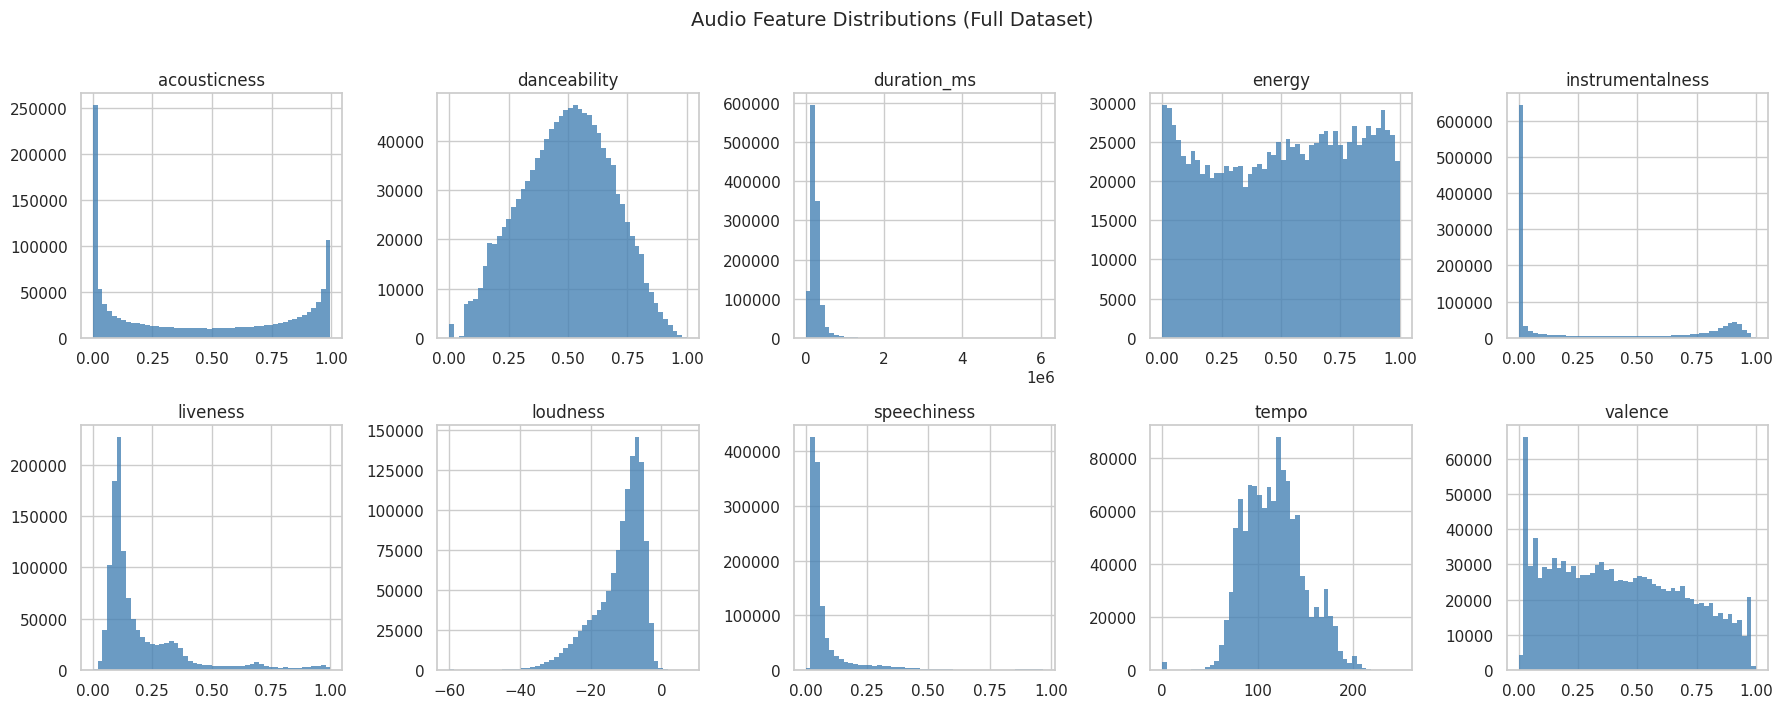

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, feat in enumerate(AUDIO_FEATURES):
    axes[i].hist(df[feat].dropna(), bins=50, color='steelblue', edgecolor='none', alpha=0.8)
    axes[i].set_title(feat)

fig.suptitle('Audio Feature Distributions (Full Dataset)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 3. Artist-Level Filtering — Radiohead

Spotify artist ID: `4Z8W4fKeB5YxbusRsdQVPb`

In [7]:
TARGET_ARTIST_ID = '4Z8W4fKeB5YxbusRsdQVPb'  # Radiohead

def artist_id_in_list(artist_ids_str: str, target_id: str) -> bool:
    try:
        return target_id in ast.literal_eval(artist_ids_str)
    except (ValueError, SyntaxError):
        return False

mask = df['artist_ids'].apply(lambda x: artist_id_in_list(str(x), TARGET_ARTIST_ID))
artist_df = df[mask].copy()

print(f'Total rows found: {len(artist_df)}')
artist_df[['name', 'album', 'release_date', 'year'] + AUDIO_FEATURES].head()

Total rows found: 224


,name,album,release_date,year,acousticness,danceability,duration_ms,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence
20113,Idioteque - Live,MTV2 Handpicked,2002-01-22,2002,0.1720,0.501,245840,0.970,0.0000,0.977,-5.798,0.1480,146.173,0.360
153011,Bloom - Jamie xx Rework Part 3,TKOL RMX 8,2011-11-18,2011,0.0219,0.616,467975,0.779,0.6900,0.312,-7.363,0.0533,126.676,0.189
153012,Separator - Anstam RMX II,TKOL RMX 8,2011-11-18,2011,0.0761,0.561,235364,0.611,0.7550,0.377,-8.209,0.1350,139.047,0.223
153013,Morning Mr Magpie - Nathan Fake Harshdub RMX,TKOL RMX 8,2011-11-18,2011,0.2830,0.686,525389,0.738,0.0345,0.103,-7.512,0.5290,139.925,0.320
529420,Burn the Witch,Burn the Witch,2016-05-04,2016,0.3030,0.540,220609,0.847,0.2720,0.109,-6.520,0.0297,148.936,0.620


In [ ]:
# Diagnóstico: álbumes presentes en el dataset
artist_df['short_album_name'] = artist_df['album'].str.split('(').str[0].str.strip()

diag = (
    artist_df
    .groupby('short_album_name')
    .agg(tracks=('name', 'count'), year=('year', 'min'))
    .sort_values('year')
)
print('Albums found in the dataset:')
print(diag.to_string())

In [ ]:
# Keep only Radiohead's 9 studio albums (exclude compilations, remixes, live albums)
STUDIO_ALBUMS = {
    'Pablo Honey',
    'The Bends',
    'OK Computer',
    'Kid A',
    'Amnesiac',
    'Hail to the Thief',
    'In Rainbows',
    'The King of Limbs',
    'A Moon Shaped Pool',
}

# Only keep rows whose short_album_name matches a studio album
artist_df = artist_df[artist_df['short_album_name'].isin(STUDIO_ALBUMS)]

# De-duplicate: one row per (album, track name)
artist_df = (
    artist_df
    .sort_values('year')
    .drop_duplicates(subset=['short_album_name', 'name'], keep='first')
    .sort_values('year')
    .reset_index(drop=True)
)

# Chronological album order
ALBUM_ORDER = (
    artist_df
    .drop_duplicates('short_album_name')
    .sort_values('year')['short_album_name']
    .tolist()
)

print(f'Tracks after cleaning: {len(artist_df)}')
print('Albums (chronological):', ALBUM_ORDER)

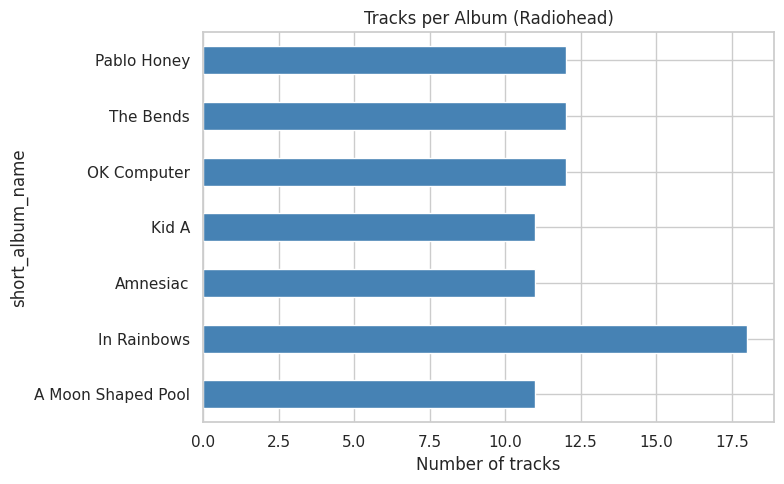

In [10]:
track_counts = (
    artist_df.groupby('short_album_name')['name']
    .count()
    .loc[ALBUM_ORDER]
)
track_counts.plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.xlabel('Number of tracks')
plt.title('Tracks per Album (Radiohead)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 4. Scatter Plot: Acousticness vs. Valence

| Feature | Range | Meaning |
|---|---|---|
| **Acousticness** | 0–1 | Confidence the track is acoustic |
| **Valence** | 0–1 | Musical positiveness (0 = sad/dark, 1 = happy/euphoric) |

Bubble size = track duration.

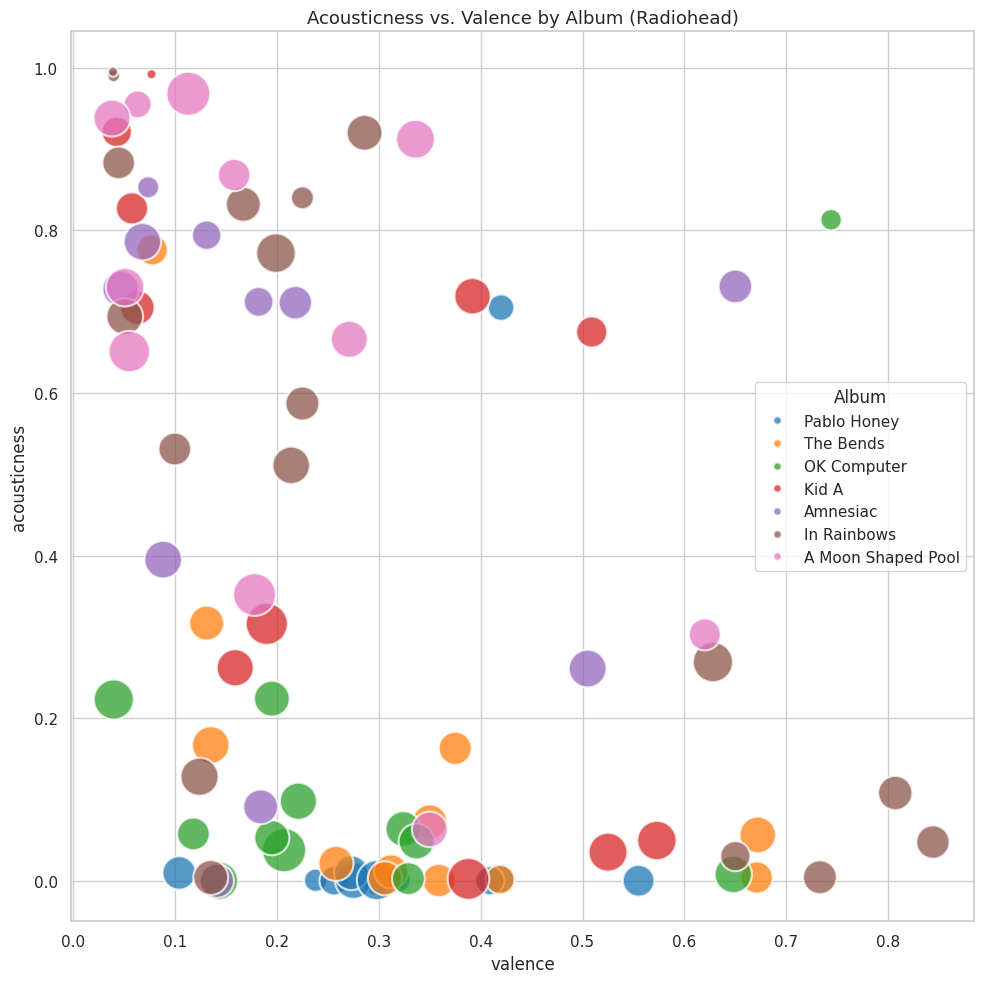

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))

sns.scatterplot(
    data=artist_df, x='valence', y='acousticness',
    hue='short_album_name', hue_order=ALBUM_ORDER,
    palette='tab10', size='duration_ms', sizes=(50, 1000),
    alpha=0.75, ax=ax
)

handles, labels = ax.get_legend_handles_labels()
n = len(ALBUM_ORDER)
ax.legend(handles[1:n+1], labels[1:n+1], title='Album', loc='best')
ax.set_title('Acousticness vs. Valence by Album (Radiohead)', fontsize=13)
plt.tight_layout()
plt.show()

## 5. Album Radar Chart

Average audio features per album, normalised to [0, 1].

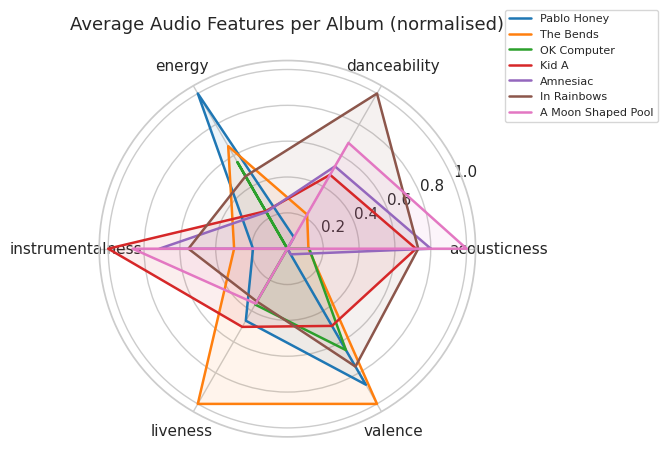

In [12]:
RADAR_FEATURES = ['acousticness', 'danceability', 'energy',
                  'instrumentalness', 'liveness', 'valence']

album_means = artist_df.groupby('short_album_name')[RADAR_FEATURES].mean().loc[ALBUM_ORDER]
album_norm  = (album_means - album_means.min()) / (album_means.max() - album_means.min() + 1e-9)

N      = len(RADAR_FEATURES)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors  = sns.color_palette('tab10', n_colors=len(album_norm))

for (album, row), color in zip(album_norm.iterrows(), colors):
    vals = row.tolist() + row.tolist()[:1]
    ax.plot(angles, vals, color=color, linewidth=1.8, label=album)
    ax.fill(angles, vals, color=color, alpha=0.08)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(RADAR_FEATURES, size=11)
ax.set_title('Average Audio Features per Album (normalised)', size=13, pad=22)
ax.legend(loc='upper right', bbox_to_anchor=(1.5, 1.15), fontsize=8)
plt.tight_layout()
plt.show()

## 6. Dimensionality Reduction

Features are **z-score standardised** before projection.

In [13]:
REDUCTION_FEATURES = [
    'acousticness', 'danceability', 'duration_ms', 'energy',
    'instrumentalness', 'liveness', 'loudness', 'tempo', 'valence'
]

X  = artist_df[REDUCTION_FEATURES].dropna()
Xs = StandardScaler().fit_transform(X)
print(f'Feature matrix shape: {Xs.shape}')

Feature matrix shape: (87, 9)


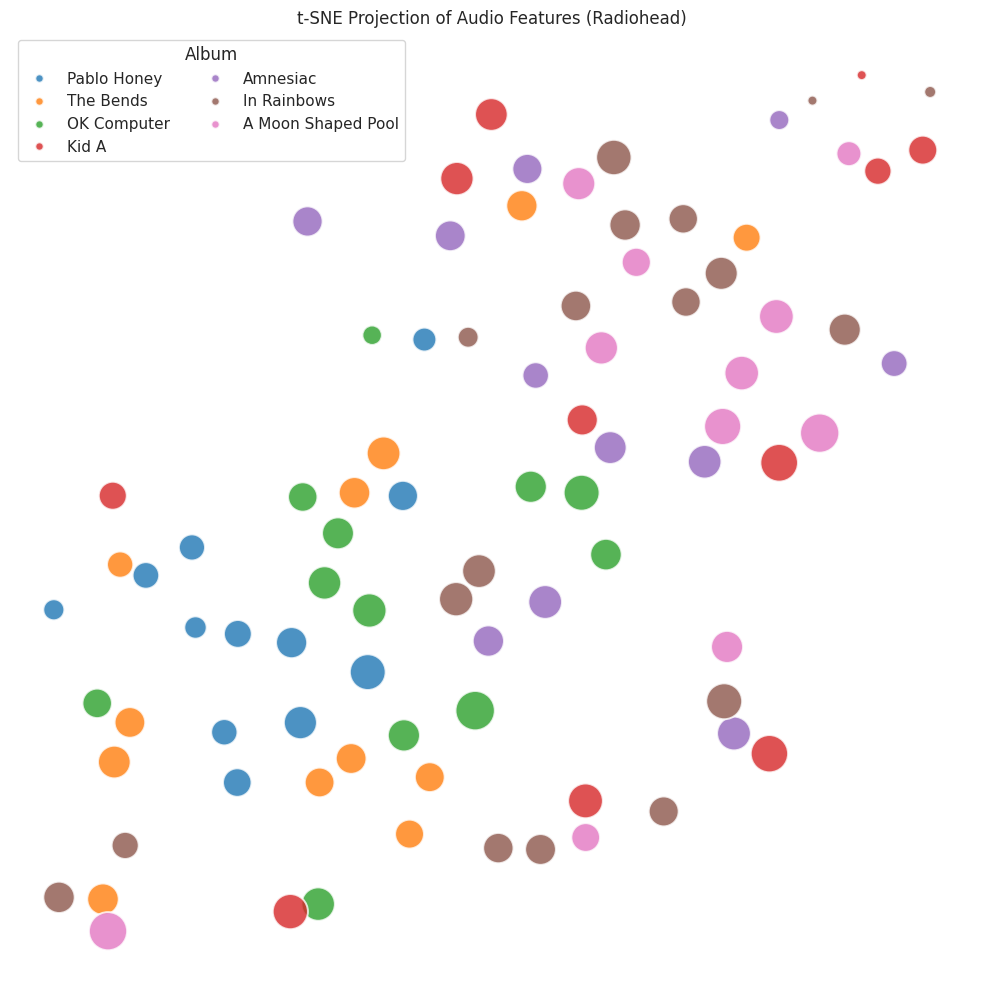

In [14]:
tsne_coords = TSNE(
    n_components=2, perplexity=min(15, len(Xs) - 1),
    random_state=3
).fit_transform(Xs)

tsne_df = pd.DataFrame(tsne_coords, columns=['x', 'y'], index=X.index)
tsne_df['short_album_name'] = artist_df.loc[X.index, 'short_album_name'].values
tsne_df['duration_ms']      = artist_df.loc[X.index, 'duration_ms'].values

plt.figure(figsize=(10, 10))
ax = sns.scatterplot(
    data=tsne_df, x='x', y='y',
    hue='short_album_name', hue_order=ALBUM_ORDER,
    palette='tab10', size='duration_ms', sizes=(50, 800), alpha=0.8
)
handles, labels = ax.get_legend_handles_labels()
n = len(ALBUM_ORDER)
ax.legend(handles[1:n+1], labels[1:n+1], loc='best', ncol=2, title='Album')
plt.title('t-SNE Projection of Audio Features (Radiohead)')
plt.axis('off')
plt.tight_layout()
plt.show()

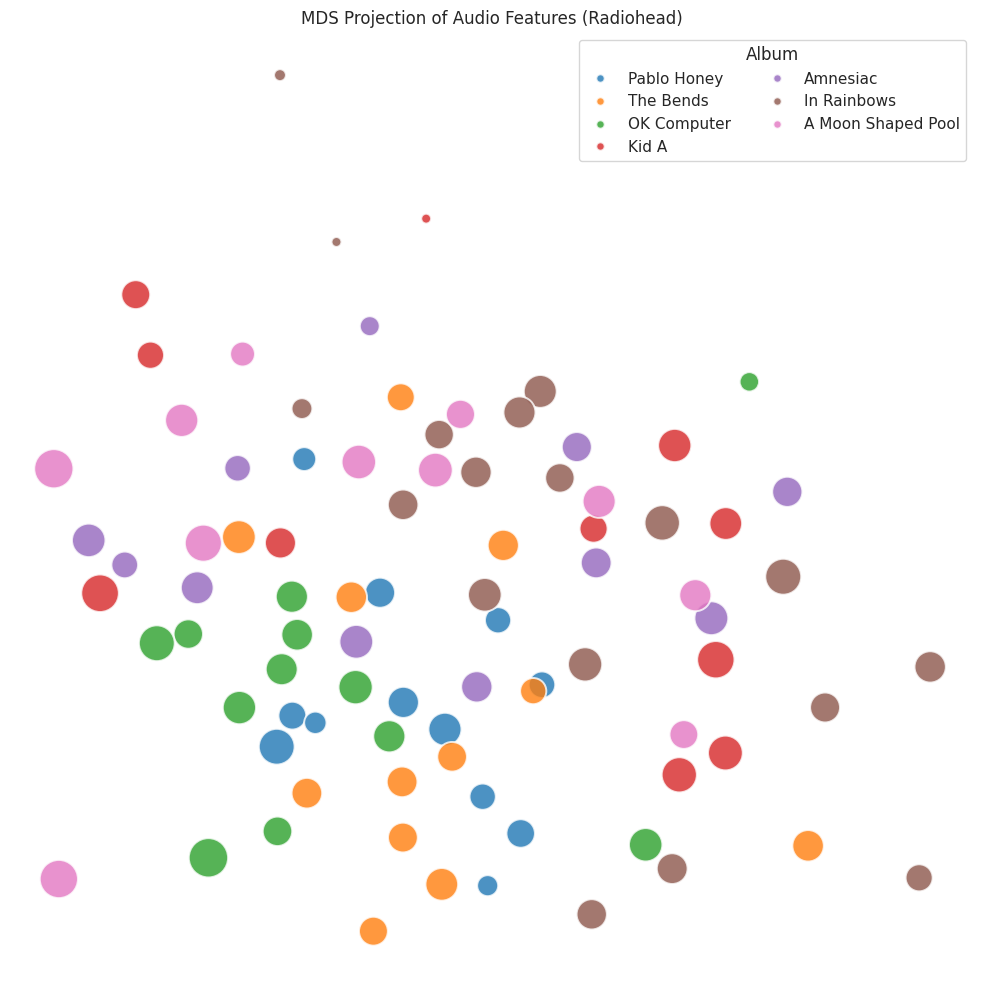

In [15]:
mds_coords = MDS(n_components=2, normalized_stress='auto', random_state=3).fit_transform(Xs)

mds_df = pd.DataFrame(mds_coords, columns=['x', 'y'], index=X.index)
mds_df['short_album_name'] = artist_df.loc[X.index, 'short_album_name'].values
mds_df['duration_ms']      = artist_df.loc[X.index, 'duration_ms'].values

plt.figure(figsize=(10, 10))
ax = sns.scatterplot(
    data=mds_df, x='x', y='y',
    hue='short_album_name', hue_order=ALBUM_ORDER,
    palette='tab10', size='duration_ms', sizes=(50, 800), alpha=0.8
)
handles, labels = ax.get_legend_handles_labels()
n = len(ALBUM_ORDER)
ax.legend(handles[1:n+1], labels[1:n+1], loc='best', ncol=2, title='Album')
plt.title('MDS Projection of Audio Features (Radiohead)')
plt.axis('off')
plt.tight_layout()
plt.show()

## 7. Key Observations

- **Acousticness vs. Valence:** Radiohead tracks tend to cluster in the low-valence region — they rarely sound 'happy'. *A Moon Shaped Pool* stands out as the most acoustic album.
- The **radar chart** captures how dramatically the sonic fingerprint changed between eras: *Pablo Honey* / *The Bends* (energetic, guitar-driven) vs. *Kid A* / *Amnesiac* (electronic, instrumental, low energy).
- **t-SNE / MDS:** the separation between early albums and the *Kid A* era is usually clearly visible in 2-D space.

---
*Tip: Change `TARGET_ARTIST_ID` and `STUDIO_ALBUMS` in Section 3 to explore any artist in the dataset.*

**APARTADO 1**

In [24]:
df.columns

Index(['id', 'name', 'album', 'album_id', 'artists', 'artist_ids',
       'track_number', 'disc_number', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms',
       'time_signature', 'year', 'release_date'],
      dtype='object')

In [17]:
radiohead_df = df[df["artists"].str.contains("Radiohead", case=False, na=False)].copy()

print("Número de canciones de Radiohead:", len(radiohead_df))
radiohead_df[["name", "album", "artists", "release_date"]].head(20)

Número de canciones de Radiohead: 224


,name,album,artists,release_date
20113,Idioteque - Live,MTV2 Handpicked,['Radiohead'],2002-01-22
153011,Bloom - Jamie xx Rework Part 3,TKOL RMX 8,"['Radiohead', 'Jamie xx']",2011-11-18
153012,Separator - Anstam RMX II,TKOL RMX 8,"['Radiohead', 'Anstam']",2011-11-18
153013,Morning Mr Magpie - Nathan Fake Harshdub RMX,TKOL RMX 8,"['Radiohead', 'Nathan Fake']",2011-11-18
529420,Burn the Witch,Burn the Witch,['Radiohead'],2016-05-04
537950,Daydreaming,Daydreaming,['Radiohead'],2016-05-06
541232,Little By Little - Caribou Rmx,TKOL RMX 1234567,"['Radiohead', 'Caribou']",2011-10-10
541233,Lotus Flower - Jacques Greene Rmx,TKOL RMX 1234567,"['Radiohead', 'Jacques Greene']",2011-10-10
541234,Morning Mr Magpie - Nathan Fake Rmx,TKOL RMX 1234567,"['Radiohead', 'Nathan Fake']",2011-10-10
541235,Bloom - Harmonic 313 Rmx,TKOL RMX 1234567,"['Radiohead', 'Harmonic 313']",2011-10-10


In [18]:
radiohead_albums = (
    radiohead_df[["album", "release_date"]]
    .dropna()
    .drop_duplicates()
    .sort_values("release_date")
    .reset_index(drop=True)
)

print("Número de álbumes distintos encontrados:", len(radiohead_albums))
radiohead_albums

Número de álbumes distintos encontrados: 40


,album,release_date
0,Drill EP,1992-05-05
1,Creep,1992-09-21
2,Anyone Can Play Guitar,1993-01-25
3,Pablo Honey,1993-02-22
4,My Iron Lung,1994-09-26
5,High & Dry / Planet Telex,1995-02-27
6,The Bends,1995-03-13
7,Fake Plastic Trees,1995-05-15
8,Just,1995-08-07
9,Street Spirit (Fade Out),1996-01-22


In [19]:
import re

EXCLUDE_WORDS = [
    "live", "deluxe", "remaster", "remastered", "expanded",
    "edition", "anniversary", "bonus", "karaoke", "instrumental",
    "acoustic", "demo", "greatest hits", "best of", "compilation",
    "collection", "soundtrack", "remix", "rmx", "ep"
]

def normalize_album(name):
    name = str(name).lower()
    name = re.sub(r"\(.*?\)", "", name)
    name = re.sub(r"\[.*?\]", "", name)
    name = re.sub(r"\s+", " ", name).strip()
    return name

def is_studio_album(name):
    name_clean = normalize_album(name)
    for word in EXCLUDE_WORDS:
        if word in name_clean:
            return False
    return True

radiohead_albums["clean_album"] = radiohead_albums["album"].apply(normalize_album)
radiohead_albums["is_studio"] = radiohead_albums["album"].apply(is_studio_album)

studio_albums = radiohead_albums[radiohead_albums["is_studio"]].copy()
studio_albums = studio_albums.drop_duplicates(subset="clean_album")

print("Álbumes de estudio detectados:", len(studio_albums))
studio_albums[["album", "release_date"]]

Álbumes de estudio detectados: 35


,album,release_date
2,Anyone Can Play Guitar,1993-01-25
3,Pablo Honey,1993-02-22
4,My Iron Lung,1994-09-26
5,High & Dry / Planet Telex,1995-02-27
6,The Bends,1995-03-13
7,Fake Plastic Trees,1995-05-15
8,Just,1995-08-07
9,Street Spirit (Fade Out),1996-01-22
10,Talk Show Host (Nellee Hooper Mix),1996-10-29
11,Paranoid Android,1997-05-26


In [21]:
# Contar cuántas canciones tiene cada álbum
album_counts = (
    radiohead_df.groupby("album")
    .size()
    .reset_index(name="num_tracks")
)

album_counts = album_counts.sort_values("num_tracks", ascending=False)

album_counts.head(20)

# Nos quedamos solo con álbumes con al menos 8 canciones
studio_albums_final = album_counts[album_counts["num_tracks"] >= 8]

print("Álbumes de estudio detectados:", len(studio_albums_final))
studio_albums_final

Álbumes de estudio detectados: 13


,album,num_tracks
31,TKOL RMX 1234567,19
9,Hail To the Thief,14
25,Pablo Honey,12
24,OK Computer,12
34,The Bends,12
0,A Moon Shaped Pool,11
19,Kid A,11
1,Amnesiac,11
15,In Rainbows,10
4,Com Lag: 2+2=5,10


In [28]:
studio_album_names = [
    "Pablo Honey",
    "The Bends",
    "OK Computer",
    "Kid A",
    "Amnesiac",
    "Hail To the Thief",
    "In Rainbows",
    "The King Of Limbs",
    "A Moon Shaped Pool"
]

studio_albums_final = album_counts[album_counts["album"].isin(studio_album_names)].copy()
studio_albums_final = studio_albums_final.sort_values("num_tracks", ascending=False)

print("Álbumes de estudio finales:", len(studio_albums_final))
studio_albums_final

Álbumes de estudio finales: 9


,album,num_tracks
9,Hail To the Thief,14
25,Pablo Honey,12
24,OK Computer,12
34,The Bends,12
0,A Moon Shaped Pool,11
19,Kid A,11
1,Amnesiac,11
15,In Rainbows,10
37,The King Of Limbs,8


In [31]:
radiohead_studio_tracks = radiohead_df[
    radiohead_df["album"].isin(studio_album_names)
].copy()

print("Número de canciones de álbumes de estudio:", len(radiohead_studio_tracks))
radiohead_studio_tracks[["name", "album", "release_date"]].head(30)
radiohead_studio_tracks.groupby("album").size().reset_index(name="num_tracks")


Número de canciones de álbumes de estudio: 101


,album,num_tracks
0,A Moon Shaped Pool,11
1,Amnesiac,11
2,Hail To the Thief,14
3,In Rainbows,10
4,Kid A,11
5,OK Computer,12
6,Pablo Honey,12
7,The Bends,12
8,The King Of Limbs,8


Para obtener únicamente los álbumes de estudio de Radiohead, primero se filtraron todas las canciones del artista dentro del dataset completo. A continuación, se identificaron los álbumes distintos y se calculó el número de canciones asociadas a cada uno, usando este criterio para detectar y descartar singles, EPs, discos en directo, recopilatorios y versiones especiales. Por último, se realizó una validación manual con la discografía oficial del grupo, seleccionando solo los álbumes de estudio y construyendo así un conjunto final limpio para el análisis posterior.

**APARTADO 2**

In [32]:
import requests

def get_lyrics(artist, title):
    url = f"https://api.lyrics.ovh/v1/{artist}/{title}"
    try:
        r = requests.get(url, timeout=10)
        if r.status_code == 200:
            data = r.json()
            return data.get("lyrics", "")
        return ""
    except:
        return ""

In [33]:
sample_tracks = radiohead_studio_tracks.head(10).copy()

sample_tracks["lyrics"] = sample_tracks["name"].apply(
    lambda x: get_lyrics("Radiohead", x)
)

sample_tracks[["name", "lyrics"]]

,name,lyrics
561190,Burn the Witch,Stay in the shadows\nCheer at the gallows\nThi...
561191,Daydreaming,Dreamers\nThey never learn\nThey never learn\n...
561192,Decks Dark,"Then in your life, there comes the darkness\nT..."
561193,Desert Island Disk,Now as I go upon my way\nSo let me go upon my ...
561194,Ful Stop,You really messed up everything\nYou really me...
561195,Glass Eyes,"Hey it's me, I just got off the train\nA frigh..."
561196,Identikit,(A moon shaped pool\nDancing clothes won't let...
561197,The Numbers,It holds us like a phantom\nThe touch is like ...
561198,Present Tense,This dance\nThis dance\nIs like a weapon\nIs l...
561199,Tinker Tailor Soldier Sailor Rich Man Poor Man...,"All the holes at once are coming alive, set fr..."


In [44]:
import re
from collections import Counter

STOPWORDS = {
    "the","and","a","an","to","of","in","on","for","is","it","you","me","my",
    "i","we","our","your","that","this","with","be","am","are","was","were",
    "do","does","did","so","but","if","not","no","yes","oh","ah","ooh","la",
    "all","can","get","got","what","when","where","who","why","how",
    "just","will","into","out","off","down","up","back","there","here",
    "don","dont","didnt","cant","wont","im","youre","theyre","ive",
    "like","know","one","two","three","yeah","hey","they","want","now",
    "come","never","let","have","from","take","around","over"
}

def clean_lyrics(text):
    text = str(text).lower()
    text = re.sub(r"\[.*?\]", " ", text)          # quita [verse], [chorus], etc.
    text = text.replace("\n", " ")
    text = re.sub(r"[^a-zA-Z\s]", " ", text)      # deja solo letras y espacios
    text = re.sub(r"\s+", " ", text).strip()
    words = [w for w in text.split() if len(w) > 2 and w not in STOPWORDS]
    return words

In [41]:
clean_lyrics(sample_tracks["lyrics"].iloc[0])[:30]

['stay',
 'shadows',
 'cheer',
 'gallows',
 'round',
 'low',
 'flying',
 'panic',
 'attack',
 'sing',
 'song',
 'jukebox',
 'goes',
 'burn',
 'witch',
 'burn',
 'witch',
 'live',
 'red',
 'crosses',
 'wooden',
 'doors',
 'float',
 'burn',
 'loose',
 'talk',
 'around',
 'tables',
 'abandon',
 'reason']

In [42]:
radiohead_studio_tracks["lyrics"] = radiohead_studio_tracks["name"].apply(
    lambda x: get_lyrics("Radiohead", x)
)

In [45]:
all_words = []

for lyrics in radiohead_studio_tracks["lyrics"]:
    words = clean_lyrics(lyrics)
    all_words.extend(words)

word_counts = Counter(all_words)

top_words = word_counts.most_common(20)

top_words

[('nothing', 34),
 ('eyes', 31),
 ('feel', 30),
 ('arms', 30),
 ('see', 28),
 ('love', 26),
 ('everything', 26),
 ('time', 26),
 ('broken', 26),
 ('try', 25),
 ('case', 25),
 ('think', 25),
 ('rain', 24),
 ('been', 24),
 ('yourself', 24),
 ('man', 24),
 ('little', 24),
 ('really', 23),
 ('world', 23),
 ('better', 23)]

El análisis de las letras de las canciones de Radiohead se ha realizado a partir del conjunto de temas pertenecientes a sus álbumes de estudio. Tras obtener las letras mediante una API externa, se ha llevado a cabo un proceso de limpieza textual que incluye la eliminación de signos de puntuación, palabras vacías y términos irrelevantes.

Posteriormente, se ha calculado la frecuencia de aparición de cada palabra en el conjunto de letras. Los resultados muestran que términos como “nothing”, “eyes”, “feel”, “love”, “time” o “broken” aparecen de forma recurrente.

Estas palabras reflejan una fuerte presencia de temáticas relacionadas con las emociones, característica propia del Radiohead. Este análisis permite identificar patrones en el contenido de sus canciones y aporta una visión general de los conceptos en su discografía.

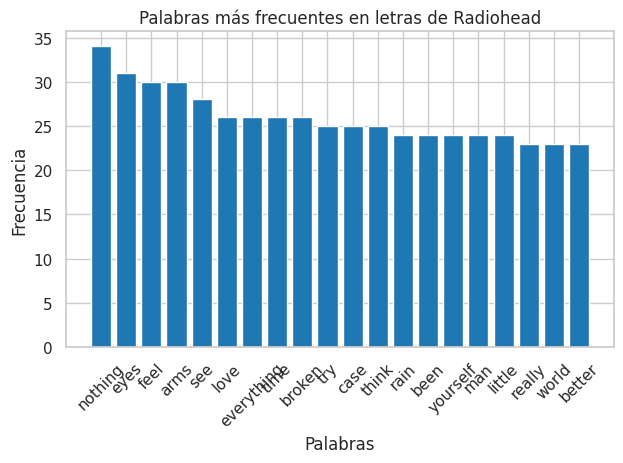

In [46]:
import matplotlib.pyplot as plt

words = [w for w, _ in top_words]
counts = [c for _, c in top_words]

plt.figure()
plt.bar(words, counts)
plt.xticks(rotation=45)
plt.title("Palabras más frecuentes en letras de Radiohead")
plt.xlabel("Palabras")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

En el gráfico se muestran las palabras más frecuentes en las letras de las canciones analizadas. Se observa que términos como “nothing”, “eyes”, “feel” y “love” presentan una alta frecuencia, lo que indica una clara predominancia de temáticas emocionales.

Asimismo, aparecen palabras relacionadas con el tiempo y la percepción, como “time”, “everything” o “broken”, lo que refuerza la idea de que las letras de Radiohead se centran la experiencia personal y la reflexión.

**APARTADO 3**

In [47]:
radiohead_studio_tracks.to_csv("radiohead_studio_tracks.csv", index=False)

In [48]:
from google.colab import files
files.download("radiohead_studio_tracks.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Esto es para descargar el csv que se utilizará en la página web